# LangChain Visual RAG — MVTec AD + Qdrant + Qwen3-VL-2B

이 노트북은 **독립 실행**을 전제로 한 Visual RAG 예제입니다.

| 구성 | 선택 |
|------|------|
| 프레임워크 | LangChain |
| 벡터 DB | Qdrant (로컬 파일 모드) |
| 임베딩 | SigLIP2 (`google/siglip2-so400m-patch14-384`) — 텍스트↔이미지 멀티모달(다국어·한글) |
| 생성 VLM | `Qwen/Qwen3-VL-2B-Instruct` |
| 데이터 | `MVTec_581MB.zip` → `./data/mvtec` (15개 카테고리) |

**파이프라인**
1. MVTec 이미지를 SigLIP2로 임베딩 → Qdrant에 인덱싱
2. 질문(텍스트/이미지)으로 유사 이미지 Top-K 검색
3. 검색된 이미지를 Qwen3-VL에 전달해 결함 분석 답변 생성
4. LangChain `create_agent` + Tools로 질의응답

---

### Visual RAG란? (초보자용)

일반 RAG(Retrieval-Augmented Generation)는 “문서를 찾아서 LLM에게 넘겨 답하게” 합니다.  
**Visual RAG**는 문서 대신 **이미지(또는 이미지+설명)** 를 찾아, **이미지를 보고 말할 수 있는 모델(VLM)** 에게 넘깁니다.

비유하면:
- **도서관 사서(검색기)**: “이 질문과 비슷한 검사 사진을 찾아줘” → SigLIP2 + Qdrant
- **전문 검사원(생성기)**: “찾은 사진을 보고 결함을 설명해줘” → Qwen3-VL

그래서 모델이 외운 지식만으로 추측하지 않고, **실제 DB에 있는 샘플 이미지**를 근거로 답하게 됩니다.


## 0. 패키지 설치

### 이 단계에서 하는 일
프로그램이 돌아가려면 필요한 **라이브러리(도구 모음)** 를 미리 설치해야 합니다.  
이 노트북은 `requirements.txt`에 적힌 패키지(torch, transformers, langchain, qdrant-client 등)를 사용합니다.

### 초보자가 알면 좋은 점
- `%pip install`은 Jupyter/노트북 안에서 pip를 실행하는 매직 명령입니다.
- 이미 설치되어 있으면 건너뛰어도 됩니다.
- GPU를 쓰려면 CUDA가 지원되는 PyTorch가 설치되어 있어야 합니다.

In [1]:
# 필요 시 실행 (최초 1회)
# 아래 주석을 해제하면 현재 커널에 requirements.txt 패키지를 설치합니다.
# %pip install -q -r requirements.txt

## 1. Import & 설정

### 이 단계에서 하는 일
앞으로 쓸 **경로, 모델 이름, 검색 개수(Top-K), GPU/CPU** 같은 “전역 설정”을 한곳에 모아 둡니다.  
코드를 수정할 때는 대부분 이 셀의 값만 바꿔도 됩니다.

### 주요 개념
- **경로(Path)**: 데이터 zip, 압축 해제 폴더, Qdrant 저장 폴더의 위치
- **임베딩 모델(SigLIP2)**: 이미/텍스트를 “비슷한 숫자 벡터”로 바꾸는 모델 (다국어·한글 쿼리에 유리)
- **VLM(Qwen3-VL)**: 이미지를 보고 문장으로 답하는 생성 모델
- **Top-K**: 검색할 때 가장 비슷한 이미지 K개만 가져오기
- **DEVICE**: 연산에 GPU(`cuda`)를 쓸지 CPU를 쓸지 자동 결정


In [2]:
from __future__ import annotations

import json
import os
import platform
import uuid
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from tqdm.auto import tqdm


def setup_korean_matplotlib() -> Optional[str]:
    """Windows / macOS / Linux에서 matplotlib 한글 폰트 설정."""
    names = {f.name for f in fm.fontManager.ttflist}
    system = platform.system()
    candidates = {
        "Windows": ("Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"),
        "Darwin": ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic"),
    }.get(system, ("NanumGothic", "NanumBarunGothic", "UnDotum"))

    chosen = next((name for name in candidates if name in names), None)
    if chosen:
        plt.rcParams["font.family"] = chosen
    else:
        print("경고: 한글 폰트를 찾지 못했습니다. 제목 한글이 깨질 수 있습니다.")
    plt.rcParams["axes.unicode_minus"] = False  # 음수 부호 깨짐 방지
    return chosen


_korean_font = setup_korean_matplotlib()
print(f"matplotlib 한글 폰트: {_korean_font or '미설정'}")

# ---- 경로 (이 노트북이 있는 프로젝트 폴더 기준) ----
# 노트북 실행 위치가 프로젝트 루트인지 확인하고 ROOT를 정합니다.
BASE_DIR = Path.cwd().resolve()
if (BASE_DIR / "MVTec_581MB.zip").exists() or (BASE_DIR / "data").exists():
    ROOT = BASE_DIR
else:
    # 노트북 cwd가 다를 경우 fallback
    # __file__은 일반 .py에서는 사용 가능하지만, 노트북에서는 없을 수 있습니다.
    ROOT = Path(__file__).resolve().parent if "__file__" in dir() else BASE_DIR

# 데이터 zip / 압축 해제 폴더(data/mvtec) / Qdrant 로컬 저장소
ZIP_PATH = ROOT / "MVTec_581MB.zip"
DATA_DIR = ROOT / "data" / "mvtec"
QDRANT_PATH = ROOT / "qdrant_storage"
# Qdrant 안에서 벡터를 모아 두는 논리 단위 이름(테이블과 비슷함)
COLLECTION_NAME = "mvtec_visual_rag_siglip2"

# ---- 모델 ----
# SigLIP2: 텍스트와 이미지를 같은 벡터 공간에 매핑 → 상호 검색 가능 (다국어·한글)
SIGLIP2_MODEL_ID = "google/siglip2-so400m-patch14-384"
# Qwen3-VL: 이미지를 보고 설명을 생성하는 Vision-Language Model
VLM_MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"

# ---- 인덱싱 / 검색 ----
CATEGORIES: Optional[List[str]] = None  # None이면 전체 카테고리
# 예: CATEGORIES = ["bottle", "screw"] 처럼 지정하면 해당 카테고리만 사용
MAX_IMAGES_PER_CATEGORY = 40            # 데모용 상한 (전체 사용 시 None)
TOP_K = 3                               # 질문당 가져올 유사 이미지 개수
BATCH_SIZE = 8                          # SigLIP2 So400M은 무거워 배치를 줄임

# GPU가 있으면 cuda, 없으면 cpu (속도/메모리에 큰 영향)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"ROOT      : {ROOT}")
print(f"DATA_DIR  : {DATA_DIR}")
print(f"DEVICE    : {DEVICE}")
print(f"CUDA avail: {torch.cuda.is_available()}")


matplotlib 한글 폰트: Malgun Gothic
ROOT      : C:\MyCursorLab\09_Visual_RAG
DATA_DIR  : C:\MyCursorLab\09_Visual_RAG\data\mvtec
DEVICE    : cuda
CUDA avail: True


## 2. 데이터셋 압축 해제

### 이 단계에서 하는 일
`MVTec_581MB.zip`을 `data/mvtec/` 폴더에 풀어 MVTec AD 이미지에 접근할 수 있게 합니다.  
이미 풀어 두었다면 다시 풀지 않고 바로 넘어갑니다.

### MVTec AD 데이터란?
공장 제품의 **정상/결함 사진**을 모아 둔 공개 데이터셋입니다.  
카테고리 예: bottle, cable, capsule, screw, wood …

### 폴더 구조 (개념)
```
data/mvtec/
  bottle/
    train/good/          ← 학습용 정상 샘플
    test/good/           ← 테스트용 정상
    test/broken_large/   ← 테스트용 결함(종류별 하위 폴더)
    ground_truth/...     ← 결함 마스크(이 노트북에서는 검색용으로 필수는 아님)
```

In [3]:
def ensure_mvtec_extracted(zip_path: Path, data_dir: Path) -> Path:
    """MVTec_581MB.zip을 data_dir에 압축 해제. 이미 있으면 건너뜀."""
    # “이미 풀렸는지”를 대표 경로 존재 여부로 간단히 판단합니다.
    marker = data_dir / "bottle" / "train" / "good"
    if marker.exists():
        print(f"[OK] 이미 압축 해제됨: {data_dir}")
        return data_dir

    if not zip_path.exists():
        raise FileNotFoundError(f"ZIP 파일을 찾을 수 없습니다: {zip_path}")

    data_dir.mkdir(parents=True, exist_ok=True)
    print(f"[INFO] 압축 해제 중... ({zip_path.name} → {data_dir})")
    # zipfile: 파이썬 표준 라이브러리로 zip을 풉니다.
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(data_dir)
    print("[OK] 압축 해제 완료")
    return data_dir


ensure_mvtec_extracted(ZIP_PATH, DATA_DIR)
# 폴더 목록(=카테고리 이름)을 확인해 데이터 준비를 검증합니다.
print("카테고리:", sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()]))

[OK] 이미 압축 해제됨: C:\MyCursorLab\09_Visual_RAG\data\mvtec
카테고리: ['bottle', 'cable', 'capsule', 'carpet', 'chroma_db', 'chroma_db_eval', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'uploads', 'wood', 'zipper']


## 3. MVTec 이미지 메타데이터 수집

### 이 단계에서 하는 일
디스크에 있는 이미지 파일을 하나씩 찾아 **메타데이터(카테고리, 정상/결함, 경로, 설명문)** 로 정리합니다.  
나중에 벡터 DB에 넣을 때 “숫자 벡터 + 부가 정보”로 함께 저장합니다.

### 왜 caption(설명 문장)이 있나?
벡터 검색의 주인공은 **이미지 임베딩**이지만, LangChain Document에는 보통 텍스트 `page_content`가 필요합니다.  
그래서 사람이 읽기 쉬운 짧은 영문 설명을 caption으로 만들어 둡니다.

### 샘플링(MAX_IMAGES_PER_CATEGORY)
데모/노트북에서는 이미지를 너무 많이 넣으면 인덱싱이 오래 걸립니다.  
카테고리마다 상한을 두고, 가능하면 **결함/정상을 균형** 있게 조금씩 가져옵니다.

In [4]:
@dataclass
class ImageRecord:
    """한 장 이미지에 대한 메타데이터를 담는 간단한 자료구조입니다."""
    path: str
    category: str
    split: str          # train | test
    label: str          # good | defect class name
    is_defect: bool
    caption: str        # 검색/문서용 텍스트

    def to_metadata(self) -> Dict[str, Any]:
        """Qdrant payload / LangChain Document metadata로 넣을 딕셔너리."""
        return {
            "path": self.path,
            "category": self.category,
            "split": self.split,
            "label": self.label,
            "is_defect": self.is_defect,
        }


def build_caption(category: str, label: str, is_defect: bool) -> str:
    """이미지 내용을 짧게 설명하는 텍스트를 만듭니다. (검색 문서용)"""
    if not is_defect:
        return (
            f"MVTec AD industrial inspection image of a {category}. "
            f"Condition: normal (good). No visible defect."
        )
    defect_name = label.replace("_", " ")
    return (
        f"MVTec AD industrial inspection image of a {category}. "
        f"Defect type: {defect_name}. Anomalous sample for quality inspection."
    )


def collect_mvtec_records(
    data_dir: Path,
    categories: Optional[Sequence[str]] = None,
    max_per_category: Optional[int] = None,
    prefer_test: bool = True,
) -> List[ImageRecord]:
    """MVTec 폴더 구조를 스캔해 ImageRecord 리스트를 만든다."""
    # data_dir 바로 아래 디렉터리 이름이 카테고리입니다.
    cats = sorted([p.name for p in data_dir.iterdir() if p.is_dir()])
    if categories:
        cats = [c for c in cats if c in set(categories)]

    records: List[ImageRecord] = []
    exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

    for cat in cats:
        cat_recs: List[ImageRecord] = []
        # prefer_test=True면 test 폴더를 먼저 훑어 결함 샘플을 더 빨리 확보합니다.
        splits = ["test", "train"] if prefer_test else ["train", "test"]
        for split in splits:
            split_dir = data_dir / cat / split
            if not split_dir.exists():
                continue
            # label_dir 예: good, cracked, scratch_head ...
            for label_dir in sorted(split_dir.iterdir()):
                if not label_dir.is_dir():
                    continue
                label = label_dir.name
                is_defect = label != "good"
                for img_path in sorted(label_dir.iterdir()):
                    if img_path.suffix.lower() not in exts:
                        continue
                    cat_recs.append(
                        ImageRecord(
                            path=str(img_path.resolve()),
                            category=cat,
                            split=split,
                            label=label,
                            is_defect=is_defect,
                            caption=build_caption(cat, label, is_defect),
                        )
                    )

        if max_per_category is not None and len(cat_recs) > max_per_category:
            # defect / good 균형을 맞추기 위해 간단 샘플링
            defects = [r for r in cat_recs if r.is_defect]
            goods = [r for r in cat_recs if not r.is_defect]
            n_def = min(len(defects), max_per_category // 2)
            n_good = min(len(goods), max_per_category - n_def)
            cat_recs = defects[:n_def] + goods[:n_good]

        records.extend(cat_recs)

    return records


records = collect_mvtec_records(
    DATA_DIR,
    categories=CATEGORIES,
    max_per_category=MAX_IMAGES_PER_CATEGORY,
)
print(f"수집된 이미지 수: {len(records)}")
from collections import Counter
print("카테고리별:", dict(Counter(r.category for r in records)))
print("결함/정상:", dict(Counter("defect" if r.is_defect else "good" for r in records)))
print("샘플 caption:", records[0].caption)

수집된 이미지 수: 551
카테고리별: {'bottle': 37, 'cable': 40, 'capsule': 40, 'carpet': 21, 'grid': 40, 'hazelnut': 40, 'leather': 40, 'metal_nut': 40, 'pill': 40, 'screw': 40, 'tile': 40, 'toothbrush': 13, 'transistor': 40, 'wood': 40, 'zipper': 40}
결함/정상: {'defect': 182, 'good': 369}
샘플 caption: MVTec AD industrial inspection image of a bottle. Defect type: broken large. Anomalous sample for quality inspection.


## 4. SigLIP2 멀티모달 임베딩 (LangChain Embeddings 호환)

### 이 단계에서 하는 일
이미지를 **고차원 숫자 벡터(임베딩)** 로 바꿉니다.  
같은 “의미/모습”의 이미지·문장은 벡터 공간에서 **가까이** 놓이도록 SigLIP2가 학습되어 있습니다.

### 왜 SigLIP2인가?
- 텍스트 쿼리(“나사 헤드 스크래치”) ↔ 이미지 검색이 가능 (**한글·다국어**에도 강함)
- 이미지 쿼리(사진 한 장) ↔ 비슷한 사진 검색도 가능
- 즉, **한 벡터 공간에서 텍스트와 이미지를 비교**할 수 있습니다.
- sigmoid loss·다국어 학습으로 한글·다국어 검색에 유리합니다.

### 기술 포인트
- `get_image_features` / `get_text_features` 결과가 버전마다 **텐서 또는 ModelOutput**일 수 있어 변환 함수로 통일합니다.
- 텍스트는 SigLIP2 학습 관례에 맞춰 `padding="max_length"`, `max_length=64`를 사용합니다.
- L2 정규화(`feats / feats.norm(...)`) 후 코사인 유사도로 비교하기 쉽게 만듭니다.
- LangChain의 `Embeddings` 인터페이스를 구현해 다른 컴포넌트와 연결하기 쉽게 합니다.


In [5]:
from langchain_core.embeddings import Embeddings
from transformers import AutoModel, AutoProcessor


def _siglip_feats_to_tensor(feats: Any) -> torch.Tensor:
    """transformers 버전에 따라 tensor 또는 ModelOutput이 올 수 있어 통일."""
    # 구버전: 바로 Tensor 반환
    if torch.is_tensor(feats):
        return feats
    # 신버전(예: 5.x): BaseModelOutputWithPooling 반환
    # 이때 pooler_output에는 이미 projection이 적용된 임베딩이 들어 있습니다.
    for key in ("image_embeds", "text_embeds", "pooler_output"):
        val = getattr(feats, key, None)
        if torch.is_tensor(val):
            return val
    if hasattr(feats, "last_hidden_state") and torch.is_tensor(feats.last_hidden_state):
        return feats.last_hidden_state[:, 0]
    if isinstance(feats, (tuple, list)) and feats:
        return _siglip_feats_to_tensor(feats[0])
    raise TypeError(f"Unexpected SigLIP2 feature type: {type(feats)}")


class SigLIP2MultimodalEmbeddings(Embeddings):
    """텍스트/이미지 모두 SigLIP2 공간으로 임베딩하는 LangChain Embeddings."""

    def __init__(self, model_id: str = SIGLIP2_MODEL_ID, device: str = DEVICE):
        self.device = device
        dtype = torch.float16 if device == "cuda" else torch.float32
        # Processor: 이미지/텍스트를 모델 입력 텐서로 변환
        self.processor = AutoProcessor.from_pretrained(model_id)
        # Model: 실제 임베딩을 계산
        self.model = AutoModel.from_pretrained(model_id, torch_dtype=dtype).to(device)
        self.model.eval()  # 추론 모드(드롭아웃 등 학습용 동작 off)
        # So400M 등: vision hidden_size(대개 1152). 없으면 샘플로 확인.
        cfg = self.model.config
        if hasattr(cfg, "vision_config") and hasattr(cfg.vision_config, "hidden_size"):
            self.dim = int(cfg.vision_config.hidden_size)
        elif hasattr(cfg, "projection_dim"):
            self.dim = int(cfg.projection_dim)
        else:
            probe = self._embed_texts(["dimension probe"])
            self.dim = len(probe[0])

    @torch.inference_mode()
    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        # LangChain Embeddings 규약: 여러 문서 텍스트 → 벡터 리스트
        return self._embed_texts(texts)

    @torch.inference_mode()
    def embed_query(self, text: str) -> List[float]:
        # LangChain Embeddings 규약: 검색 쿼리 1개 → 벡터 1개
        return self._embed_texts([text])[0]

    @torch.inference_mode()
    def _embed_texts(self, texts: List[str]) -> List[List[float]]:
        # SigLIP2 학습 시와 동일: max_length=64 + max_length 패딩
        inputs = self.processor(
            text=texts,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=64,
        )
        # text 관련 키만 전달 (버전별 processor 출력 차이 방지)
        text_inputs = {
            k: v.to(self.device)
            for k, v in inputs.items()
            if k in ("input_ids", "attention_mask", "position_ids")
        }
        feats = _siglip_feats_to_tensor(self.model.get_text_features(**text_inputs))
        # 단위 벡터로 정규화 → 코사인 유사도 = 내적
        feats = feats / feats.norm(dim=-1, keepdim=True).clamp_min(1e-12)
        return feats.cpu().float().numpy().tolist()

    @torch.inference_mode()
    def embed_images(self, image_paths: Sequence[str]) -> List[List[float]]:
        images = [Image.open(p).convert("RGB") for p in image_paths]
        inputs = self.processor(images=images, return_tensors="pt")
        image_inputs = {
            k: v.to(self.device)
            for k, v in inputs.items()
            if k == "pixel_values"
        }
        feats = _siglip_feats_to_tensor(self.model.get_image_features(**image_inputs))
        feats = feats / feats.norm(dim=-1, keepdim=True).clamp_min(1e-12)
        return feats.cpu().float().numpy().tolist()


siglip2_embeddings = SigLIP2MultimodalEmbeddings()
print(f"SigLIP2 embedding dim: {siglip2_embeddings.dim}")


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

SigLIP2 embedding dim: 1152


## 5. Qdrant 컬렉션 생성 & 인덱싱

### 이 단계에서 하는 일
모든 이미지 벡터를 **Qdrant**에 저장합니다.  
이후 질문 벡터와 가장 비슷한(가까운) 벡터들을 빠르게 찾을 수 있습니다.

### 벡터 DB란?
관계형 DB가 “행/열”을 저장한다면, 벡터 DB는 **유사도 검색에 특화된 저장소**입니다.  
“이 벡터와 비슷한 top-k는?”을 빠르게 답합니다.

### 로컬 파일 모드
`QdrantClient(path=...)`는 서버 없이 폴더에 DB를 저장합니다.  
나중에 서버형(`url="http://localhost:6333"`)으로 바꿔도 개념은 같습니다.

### upsert
같은 id를 다시 넣으면 갱신되고, 없으면 새로 추가됩니다.  
여기서는 매번 새 uuid를 쓰므로 “추가”에 가깝습니다.

In [6]:
from qdrant_client import QdrantClient
from qdrant_client.http import models as qm

# 로컬 디스크에 Qdrant 데이터 디렉터리를 만들고 클라이언트를 엽니다.
QDRANT_PATH.mkdir(parents=True, exist_ok=True)
qdrant = QdrantClient(path=str(QDRANT_PATH))


def recreate_collection(client: QdrantClient, name: str, dim: int) -> None:
    """컬렉션을 깨끗이 다시 만듭니다. (데모에서 재실행 시 중복 방지)"""
    existing = [c.name for c in client.get_collections().collections]
    if name in existing:
        client.delete_collection(name)
        print(f"[INFO] 기존 컬렉션 삭제: {name}")
    client.create_collection(
        collection_name=name,
        # COSINE: 방향(각도) 유사도. L2 정규화 벡터와 잘 맞습니다.
        vectors_config=qm.VectorParams(size=dim, distance=qm.Distance.COSINE),
    )
    print(f"[OK] 컬렉션 생성: {name} (dim={dim})")


def index_records(
    client: QdrantClient,
    collection: str,
    records: List[ImageRecord],
    embedder: SigLIP2MultimodalEmbeddings,
    batch_size: int = 16,
) -> int:
    """이미지 임베딩을 Qdrant에 upsert. 문서 텍스트는 caption."""
    total = 0
    for i in tqdm(range(0, len(records), batch_size), desc="Indexing"):
        batch = records[i : i + batch_size]
        # 배치 단위로 GPU/CPU 임베딩 → 속도 ↑
        vectors = embedder.embed_images([r.path for r in batch])
        points = []
        for rec, vec in zip(batch, vectors):
            payload = rec.to_metadata()
            payload["page_content"] = rec.caption  # LangChain Document content
            points.append(
                qm.PointStruct(
                    id=str(uuid.uuid4()),  # 포인트 고유 ID
                    vector=vec,            # 검색에 쓰이는 숫자 벡터
                    payload=payload,       # 검색 후 함께 돌아오는 메타데이터
                )
            )
        client.upsert(collection_name=collection, points=points)
        total += len(points)
    return total


recreate_collection(qdrant, COLLECTION_NAME, siglip2_embeddings.dim)
n_indexed = index_records(qdrant, COLLECTION_NAME, records, siglip2_embeddings, BATCH_SIZE)
info = qdrant.get_collection(COLLECTION_NAME)
print(f"인덱싱 완료: {n_indexed} points, status={info.status}")


[INFO] 기존 컬렉션 삭제: mvtec_visual_rag_siglip2
[OK] 컬렉션 생성: mvtec_visual_rag_siglip2 (dim=1152)


Indexing:   0%|          | 0/69 [00:00<?, ?it/s]

인덱싱 완료: 551 points, status=green


## 6. LangChain Retriever (텍스트 / 이미지 쿼리)

### 이 단계에서 하는 일
질문을 받아 “비슷한 이미지 Document 목록”을 돌려주는 **Retriever**를 만듭니다.  
LangChain에서는 RAG의 검색 단계를 `BaseRetriever`로 표준화합니다.

### 동작 흐름
1. 입력이 **텍스트**면 → SigLIP2 텍스트 임베딩
2. 입력이 **이미지 파일 경로**면 → SigLIP2 이미지 임베딩
3. 그 벡터로 Qdrant에서 Top-K 이웃 검색
4. 결과를 LangChain `Document`(내용+metadata)로 변환

### score란?
코사인 유사도에 기반한 점수입니다.  
값이 클수록(대개) 쿼리와 더 비슷하다고 해석합니다.


In [7]:
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document
from langchain_core.retrievers import BaseRetriever
from pydantic import ConfigDict, Field


class QdrantVisualRetriever(BaseRetriever):
    """SigLIP2 텍스트/이미지 쿼리로 Qdrant에서 유사 이미지를 검색."""

    # client/embedder처럼 일반 객체를 필드로 두려면 arbitrary_types_allowed 필요
    model_config = ConfigDict(arbitrary_types_allowed=True)

    client: Any = Field(exclude=True)
    embedder: Any = Field(exclude=True)
    collection_name: str = COLLECTION_NAME
    k: int = TOP_K

    def _search(self, vector: List[float], k: Optional[int] = None) -> List[Document]:
        limit = k or self.k
        # qdrant-client 신/구 API 모두 지원
        try:
            # 신 API: query_points
            result = self.client.query_points(
                collection_name=self.collection_name,
                query=vector,
                limit=limit,
                with_payload=True,
            )
            hits = result.points
        except Exception:
            # 구 API: search
            hits = self.client.search(
                collection_name=self.collection_name,
                query_vector=vector,
                limit=limit,
                with_payload=True,
            )
        docs: List[Document] = []
        for hit in hits:
            payload = dict(hit.payload or {})
            # page_content는 Document 본문, 나머지는 metadata로 분리
            content = payload.pop("page_content", "")
            payload["score"] = float(hit.score)
            docs.append(Document(page_content=content, metadata=payload))
        return docs

    def _get_relevant_documents(
        self, query: str, *, run_manager: CallbackManagerForRetrieverRun
    ) -> List[Document]:
        # LangChain이 retriever.invoke(query) 할 때 호출되는 핵심 메서드
        # 이미지 경로가 들어오면 이미지 임베딩, 아니면 텍스트 임베딩
        q = query.strip().strip('"').strip("'")
        if os.path.isfile(q) and Path(q).suffix.lower() in {
            ".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"
        }:
            vector = self.embedder.embed_images([q])[0]
        else:
            vector = self.embedder.embed_query(q)
        return self._search(vector)

    def retrieve_by_image(self, image_path: str, k: Optional[int] = None) -> List[Document]:
        """이미지→이미지 검색 전용 헬퍼 (경로를 명시적으로 넘길 때 사용)."""
        vector = self.embedder.embed_images([image_path])[0]
        return self._search(vector, k=k)


retriever = QdrantVisualRetriever(
    client=qdrant,
    embedder=siglip2_embeddings,
    collection_name=COLLECTION_NAME,
    k=TOP_K,
)

# 스모크 테스트
# 인덱싱/검색이 정상인지 한글·영어 쿼리로 빠르게 확인합니다.
demo_docs = retriever.invoke("오염 결함이 있는 깨진 병")
for i, d in enumerate(demo_docs, 1):
    print(f"[{i}] score={d.metadata.get('score'):.4f} | {d.metadata.get('category')}/{d.metadata.get('label')} | {Path(d.metadata['path']).name}")


[1] score=0.1224 | bottle/broken_large | 000.png
[2] score=0.1224 | bottle/broken_large | 000.png
[3] score=0.1224 | bottle/broken_large | 000.png


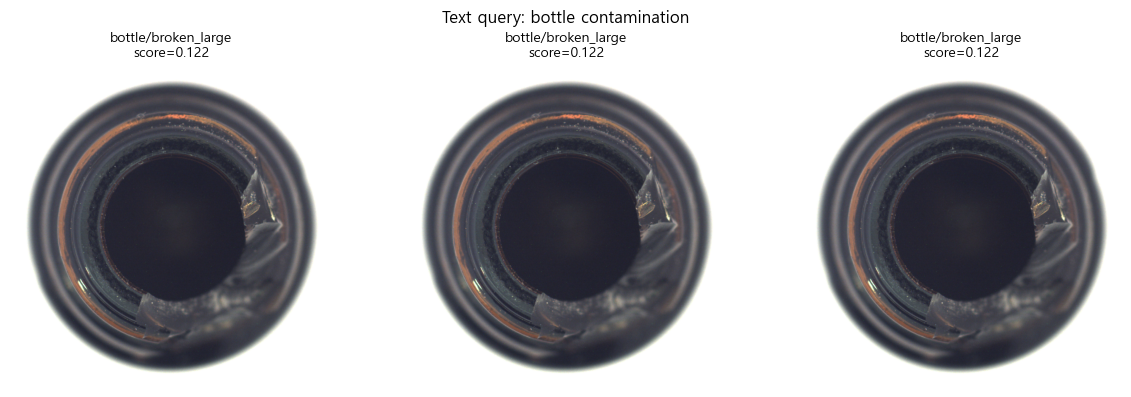

In [8]:
def show_retrieved(docs: List[Document], title: str = "Retrieved") -> None:
    """검색된 Document들의 실제 이미지를 matplotlib으로 나란히 보여줍니다."""
    n = len(docs)
    if n == 0:
        print("검색 결과 없음")
        return
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, doc in zip(axes, docs):
        img = Image.open(doc.metadata["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(
            f"{doc.metadata.get('category')}/{doc.metadata.get('label')}\n"
            f"score={doc.metadata.get('score', 0):.3f}",
            fontsize=10,
        )
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_retrieved(demo_docs, "Text query: bottle contamination")

## 7. Qwen3-VL-2B 로드 (생성용 VLM)

### 이 단계에서 하는 일
검색으로 찾은 이미지를 **보고 문장 답변을 만드는** Vision-Language Model을 로드합니다.

### SigLIP2 vs Qwen3-VL 역할 분담
| 모델 | 역할 | 출력 |
|------|------|------|
| SigLIP2 | 비슷한 이미지 찾기(검색) | 숫자 벡터 / 순위 |
| Qwen3-VL | 이미지를 보고 설명·진단(생성) | 자연어 문장 |

### 메모리/속도 팁
- GPU면 `bfloat16`/`float16`으로 VRAM을 아끼고 속도를 올립니다.
- CPU도 되지만 생성은 느릴 수 있습니다.
- 모델은 Hugging Face Hub에서 처음 받을 때 다운로드 시간이 걸립니다.


In [9]:
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration

print(f"Loading VLM: {VLM_MODEL_ID} ...")
# Processor: 채팅 템플릿 + 이미지/텍스트 전처리 + 토크나이즈
vlm_processor = AutoProcessor.from_pretrained(VLM_MODEL_ID)

# GPU 지원 정밀도 선택 (bf16 > fp16 > fp32 순으로 선호)
dtype = torch.bfloat16 if DEVICE == "cuda" and torch.cuda.is_bf16_supported() else (
    torch.float16 if DEVICE == "cuda" else torch.float32
)

vlm = Qwen3VLForConditionalGeneration.from_pretrained(
    VLM_MODEL_ID,
    torch_dtype=dtype,
    # GPU가 여러 장이면 자동 배치, 단일 GPU도 device_map="auto"가 편리합니다.
    device_map="auto" if DEVICE == "cuda" else None,
)
if DEVICE == "cpu":
    vlm = vlm.to(DEVICE)
vlm.eval()  # 추론 모드
print("[OK] Qwen3-VL-2B ready")

Loading VLM: Qwen/Qwen3-VL-2B-Instruct ...


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

[OK] Qwen3-VL-2B ready


In [10]:
def qwen3_vl_generate(
    question: str,
    image_paths: Optional[Sequence[str]] = None,
    max_new_tokens: int = 512,
) -> str:
    """검색된 이미지들 + 질문을 Qwen3-VL에 전달해 답변 생성. 이미지가 없으면 텍스트만 사용."""
    image_paths = list(image_paths or [])
    # Qwen chat 포맷: content는 [{type:image,...}, {type:text,...}] 리스트
    content: List[Dict[str, Any]] = []
    for pth in image_paths:
        content.append({"type": "image", "image": str(pth)})
    content.append({"type": "text", "text": question})

    messages = [{"role": "user", "content": content}]
    # apply_chat_template: 모델이 기대하는 특수 토큰/역할을 포함한 입력으로 변환
    inputs = vlm_processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,  # assistant가 이어서 말하도록 프롬프트 추가
        return_dict=True,
        return_tensors="pt",
    )
    inputs = {k: v.to(vlm.device) if hasattr(v, "to") else v for k, v in inputs.items()}

    with torch.inference_mode():
        output_ids = vlm.generate(**inputs, max_new_tokens=max_new_tokens)

    # generate 결과에는 “입력 토큰 + 새로 생성한 토큰”이 함께 들어 있으므로
    # 입력 길이만큼 잘라 새로 생성된 부분만 디코딩합니다.
    trimmed = [
        out[len(inp) :] for inp, out in zip(inputs["input_ids"], output_ids)
    ]
    text = vlm_processor.batch_decode(
        trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]
    return text.strip()


# 간단 스모크: 첫 번째 검색 이미지에 대해 짧은 설명
if demo_docs:
    smoke = qwen3_vl_generate(
        "이 산업용 검사 이미지에서 보이는 객체의 종류와 정상/결함 여부를 한 문장으로 설명하세요.",
        [demo_docs[0].metadata["path"]],
        max_new_tokens=128,
    )
    print("VLM smoke:", smoke)

VLM smoke: 이 이미지는 산업용 검사에서 보이는 검사 장비의 라벨을 담고 있으며, 정상 상태입니다.


## 8. Visual RAG 체인 (Retrieve → Generate)

### 이 단계에서 하는 일
검색(Retriever)과 생성(VLM)을 이어 **완성된 Visual RAG 함수**를 만듭니다.

### 두 가지 질의 방식
1. **텍스트 → 이미지 RAG** (`visual_rag_run`)  
   예: “캡슐 crack 결함 특징은?”
2. **이미지 → 이미지 RAG** (`visual_rag_by_image`)  
   예: 새 검사 사진 한 장을 주고, DB의 유사 샘플과 비교 진단

### 프롬프트에 메타데이터를 넣는 이유
VLM이 “무엇을 보고 있는지”를 더 정확히 이해하도록,  
검색된 샘플의 category/label/score를 텍스트로도 함께 제공합니다.  
다만 최종 판단은 **실제 픽셀(이미지)** 을 보는 쪽에 무게를 둡니다.

In [11]:
from langchain_core.runnables import RunnableLambda


# VLM에게 역할을 고정하는 시스템 지침(검사 전문가 톤)
RAG_SYSTEM_INSTRUCTION = """당신은 산업용 외관 검사(Visual Inspection) 전문가입니다.
아래에 검색된 MVTec AD 참고 이미지들이 주어집니다.
이미지를 관찰하고 질문에 답하세요.

규칙:
- 카테고리(제품 종류), 정상/결함, 결함 유형을 구분하세요.
- 참고 이미지의 메타정보(카테고리/라벨)를 활용하되, 실제 보이는 내용과 함께 설명하세요.
- 확실하지 않으면 근거를 들어 불확실성을 밝히세요.
- 한국어로 간결하게 답하세요.
"""


def format_context_block(docs: List[Document]) -> str:
    """검색 결과를 사람이/모델이 읽기 쉬운 텍스트 블록으로 변환."""
    lines = []
    for i, d in enumerate(docs, 1):
        lines.append(
            f"[참고 {i}] category={d.metadata.get('category')}, "
            f"label={d.metadata.get('label')}, "
            f"split={d.metadata.get('split')}, "
            f"score={d.metadata.get('score', 0):.4f}, "
            f"path={Path(d.metadata.get('path', '')).name}"
        )
    return "\n".join(lines)


def visual_rag_run(query: str, k: int = TOP_K, show: bool = True) -> Dict[str, Any]:
    """텍스트 질의 → 이미지 검색 → Qwen3-VL 답변."""
    docs = retriever.invoke(query)[:k]
    if show:
        show_retrieved(docs, title=f"Query: {query[:60]}")

    image_paths = [d.metadata["path"] for d in docs]
    context = format_context_block(docs)
    prompt = (
        f"{RAG_SYSTEM_INSTRUCTION}\n\n"
        f"검색된 참고 이미지 메타데이터:\n{context}\n\n"
        f"질문: {query}"
    )
    answer = qwen3_vl_generate(prompt, image_paths)
    return {"query": query, "documents": docs, "answer": answer}


def visual_rag_by_image(
    image_path: str,
    question: str = "이 이미지와 가장 유사한 결함/정상 샘플을 참고해, 현재 이미지의 상태를 진단하세요.",
    k: int = TOP_K,
    show: bool = True,
) -> Dict[str, Any]:
    """쿼리 이미지 → 유사 이미지 검색 → Qwen3-VL 진단."""
    docs = retriever.retrieve_by_image(image_path, k=k)
    if show:
        # 쿼리 이미지 + 검색 결과
        fig, axes = plt.subplots(1, 1 + len(docs), figsize=(4 * (1 + len(docs)), 4))
        axes = np.atleast_1d(axes)
        axes[0].imshow(Image.open(image_path).convert("RGB"))
        axes[0].set_title("QUERY")
        axes[0].axis("off")
        for ax, doc in zip(axes[1:], docs):
            ax.imshow(Image.open(doc.metadata["path"]).convert("RGB"))
            ax.set_title(
                f"{doc.metadata.get('category')}/{doc.metadata.get('label')}\n"
                f"{doc.metadata.get('score', 0):.3f}"
            )
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    # 쿼리 이미지를 맨 앞에 두고 VLM에 전달
    # (첫 장=분석 대상, 나머지=참고 샘플)
    image_paths = [image_path] + [d.metadata["path"] for d in docs]
    context = format_context_block(docs)
    prompt = (
        f"{RAG_SYSTEM_INSTRUCTION}\n\n"
        f"첫 번째 이미지가 분석 대상(QUERY)입니다. 나머지는 DB에서 검색된 참고 이미지입니다.\n"
        f"참고 이미지 메타데이터:\n{context}\n\n"
        f"질문: {question}"
    )
    answer = qwen3_vl_generate(prompt, image_paths)
    return {"query_image": image_path, "documents": docs, "answer": answer}


# LangChain Runnable 래핑
# .invoke("질문") 형태로 체인처럼 호출할 수 있게 합니다.
visual_rag_chain = RunnableLambda(lambda q: visual_rag_run(q if isinstance(q, str) else q["query"]))
print("[OK] Visual RAG chain ready")

[OK] Visual RAG chain ready


## 9. 예제 질의 (텍스트 Visual RAG)

### 이 단계에서 하는 일
자연어 질문으로 전체 파이프라인(검색→생성)을 실행해 봅니다.

### 좋은 질문 만드는 팁
- 카테고리 단어 포함: capsule, wood, screw …
- 결함 유형 힌트: crack, scratch, hole, contamination …
- “특징/원인/정상 대비 차이”처럼 **무엇을 알고 싶은지**를 명확히

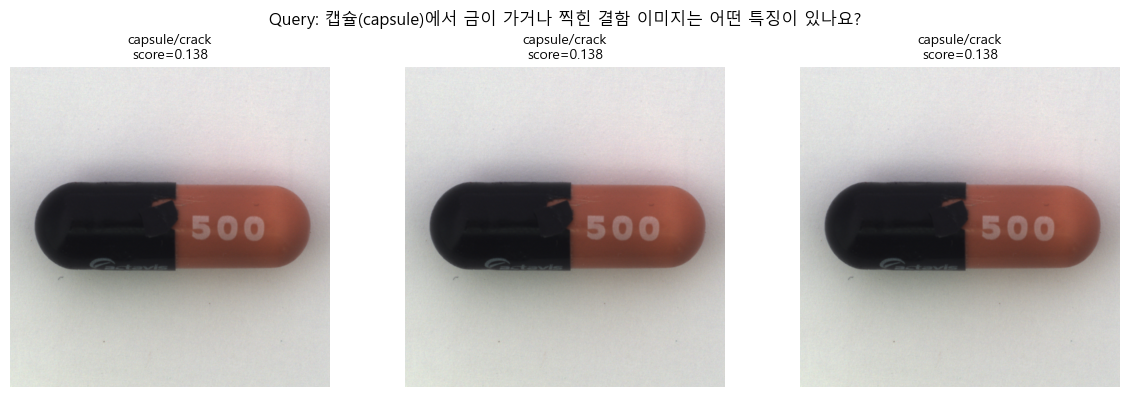

ANSWER
이미지에서 보이는 캡슐은 금이 가거나 찍힌 결함이 있습니다. 이 결함은 캡슐의 외부 표면에 있는 검은색 부분에서 오른쪽으로 흐르는 밝은 색의 금이가 있습니다. 결함의 특징은 다음과 같습니다:

- **결함 유형**: 금이, 찍힘
- **위치**: 검은색 부분의 왼쪽
- **특징**: 결함은 검은색 부분에서 오른쪽으로 흐르는 밝은 색의 금이가 있습니다.


In [12]:
# 한국어 질문 예제: 캡슐 결함의 시각적 특징을 물어봅니다.
result_text = visual_rag_run(
    "캡슐(capsule)에서 금이 가거나 찍힌 결함 이미지는 어떤 특징이 있나요?",
    k=3,
)
print("=" * 60)
print("ANSWER")
print("=" * 60)
print(result_text["answer"])

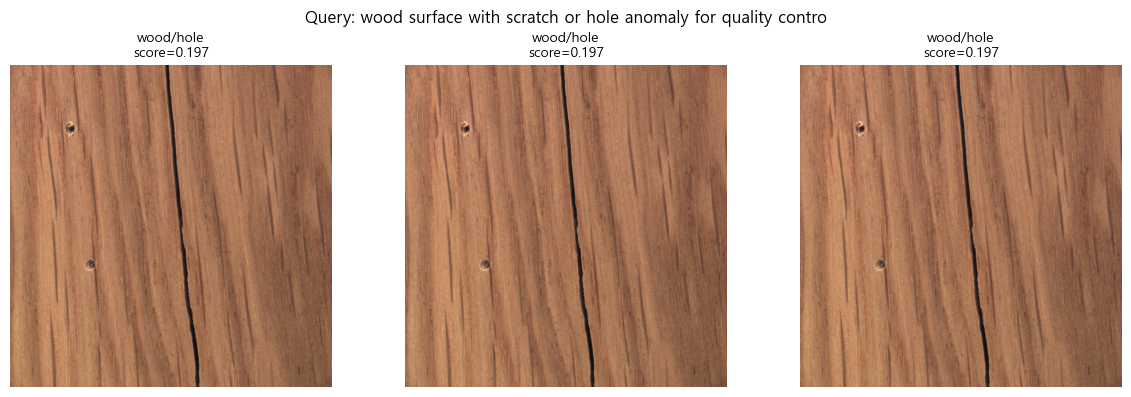

ANSWER
이미지의 주된 특징은 목재 표면에 있는 두 개의 절단된 구멍과 중앙에 있는 긴 갈라진 빈 공간입니다. 이는 목재 표면에 있는 결함입니다.  
- **카테고리**: wood  
- **정상/결함**: 결함  
- **결함 유형**: 구멍, 갈라짐  

이러한 결함은 제품의 외관에 영향을 미칠 수 있으므로, 산업용 외관 검사에서 중요합니다.


In [13]:
# 영어 질문 예제: SigLIP2는 다국어 모델이라 영문 쿼리도 잘 동작합니다.
result_text2 = visual_rag_run(
    "wood surface with scratch or hole anomaly for quality control",
    k=3,
)
print("=" * 60)
print("ANSWER")
print("=" * 60)
print(result_text2["answer"])


## 10. 예제 질의 (이미지 → 이미지 Visual RAG)

### 이 단계에서 하는 일
“새 사진 한 장”을 쿼리로 넣어, DB에서 비슷한 검사 샘플을 찾고 진단을 받습니다.

### 현장에서의 의미
라인에서 찍힌 불량 의심 사진을 넣으면,  
과거 유사 사례(라벨 포함)를 참고해 **결함 유형 후보**를 제시하는 흐름과 비슷합니다.

Query image: C:\MyCursorLab\09_Visual_RAG\data\mvtec\bottle\test\broken_large\000.png
GT label: broken_large / bottle


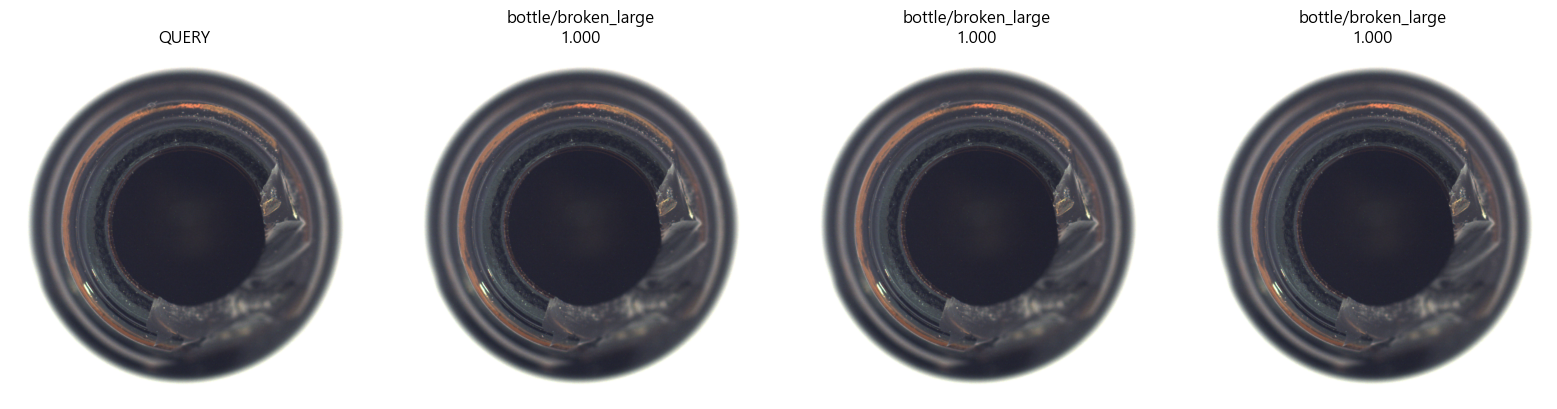

ANSWER
- **제품 종류**: 병 (bottle)
- **결함 여부**: 예, 결함 존재
- **결함 유형**: 파손 (damage)

**설명**: 분석 대상 이미지와 참고 이미지의 메타데이터를 비교할 때, 참고 이미지들은 모두 'broken_large'라는 라벨을 가진 이미지로, 제품이 파손된 상태임을 나타냅니다. 분석 대상 이미지 역시 같은 형태의 병이며, 라벨이 'broken_large'로 표시되어 있음을 확인할 수 있습니다. 따라서 분석 대상 이미지의 결함 유형은 '파손'으로 간주됩니다. 참고 이미지들과의 비교 결과, 분석 대상 이미지의 결함은 참고 이미지와 동일한 유형으로, 즉 '파손'이라는 결함 유형에 가장 가까운 것으로 판단됩니다.


In [14]:
# 테스트셋에서 임의의 결함 이미지 하나 선택
defect_candidates = [r for r in records if r.is_defect and r.split == "test"]
query_image = defect_candidates[0].path if defect_candidates else records[0].path
print("Query image:", query_image)
# GT(정답 라벨)도 함께 출력해, 모델 답과 비교해 볼 수 있습니다.
print("GT label:", Path(query_image).parent.name, "/", Path(query_image).parts[-4])

result_img = visual_rag_by_image(
    query_image,
    question=(
        "분석 대상 이미지의 제품 종류와 결함 여부를 진단하고, "
        "참고 이미지와 비교해 어떤 결함 유형에 가장 가까운지 설명하세요."
    ),
    k=3,
)
print("=" * 60)
print("ANSWER")
print("=" * 60)
print(result_img["answer"])

## 11. LangChain Agent (`create_agent`) + Tools

`langchain.agents.create_agent()`로 Visual RAG 도구를 묶은 Agent를 생성합니다.

- Model: 로컬 `Qwen3-VL-2B`를 LangChain `BaseChatModel`로 래핑 (tool calling 지원)
- Tools: `search_similar_images` / `visual_inspect` / `diagnose_image`
- Agent loop: 모델이 `tool_calls`를 반환하면 도구 실행 → 다시 모델 호출 (종료 시까지)

### Agent가 필요한 이유 (초보자용)
질문을 받을 때마다 사람이 “지금은 검색만, 이번에는 진단”을 고르지 않아도 됩니다.  
모델이 상황에 맞는 **도구(Tool)** 를 고르고, 도구 결과를 보고 최종 답을 정리합니다.

### Tool Calling이란?
모델이 평범한 문장 대신  
`{"tool": "visual_inspect", "arguments": {"query": "..."}}`  
같은 **구조화된 호출 요청**을 내고, 프레임워크가 실제 함수를 실행해 주는 방식입니다.


In [15]:
from langchain_core.tools import tool


# @tool: 일반 파이썬 함수를 LangChain Tool로 바꿉니다.
# docstring이 모델에게 “이 도구는 언제 쓰는지”를 알려 주는 설명이 됩니다.


@tool
def search_similar_images(query: str) -> str:
    """MVTec Visual RAG DB에서 텍스트 또는 이미지 경로로 유사 이미지를 검색합니다.
    입력: 자연어 검색문 또는 로컬 이미지 파일 경로.
    반환: Top-K 검색 결과의 메타데이터 JSON.
    """
    docs = retriever.invoke(query)
    payload = []
    for d in docs:
        payload.append(
            {
                "category": d.metadata.get("category"),
                "label": d.metadata.get("label"),
                "split": d.metadata.get("split"),
                "score": d.metadata.get("score"),
                "path": d.metadata.get("path"),
                "caption": d.page_content,
            }
        )
    return json.dumps(payload, ensure_ascii=False, indent=2)


@tool
def visual_inspect(query: str) -> str:
    """유사 이미지를 검색한 뒤 Qwen3-VL로 결함/정상 여부를 분석합니다.
    입력: 검사 관련 자연어 질문.
    반환: VLM 분석 결과 텍스트.
    """
    # show=False: Agent 실행 중에는 그래프 창을 띄우지 않음
    out = visual_rag_run(query, k=TOP_K, show=False)
    meta = [
        {
            "category": d.metadata.get("category"),
            "label": d.metadata.get("label"),
            "score": d.metadata.get("score"),
        }
        for d in out["documents"]
    ]
    return json.dumps({"retrieved": meta, "answer": out["answer"]}, ensure_ascii=False)


@tool
def diagnose_image(image_path: str) -> str:
    """로컬 이미지 경로를 받아 유사 샘플을 검색하고 결함을 진단합니다.
    입력: 분석할 이미지의 절대/상대 경로.
    반환: VLM 진단 결과 텍스트(JSON).
    """
    if not os.path.isfile(image_path):
        return json.dumps({"error": f"파일을 찾을 수 없습니다: {image_path}"}, ensure_ascii=False)
    out = visual_rag_by_image(image_path, show=False)
    meta = [
        {
            "category": d.metadata.get("category"),
            "label": d.metadata.get("label"),
            "score": d.metadata.get("score"),
        }
        for d in out["documents"]
    ]
    return json.dumps({"retrieved": meta, "answer": out["answer"]}, ensure_ascii=False)


# 이름 → Tool 객체 매핑 (디버깅/수동 호출용)
TOOLS = {
    "search_similar_images": search_similar_images,
    "visual_inspect": visual_inspect,
    "diagnose_image": diagnose_image,
}
print("등록된 도구:", list(TOOLS.keys()))


등록된 도구: ['search_similar_images', 'visual_inspect', 'diagnose_image']


In [16]:
import re
import uuid

from langchain.agents import create_agent
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.outputs import ChatGeneration, ChatResult
from langchain_core.utils.function_calling import convert_to_openai_tool


class Qwen3VLChatModel(BaseChatModel):
    """로컬 Qwen3-VL을 LangChain ChatModel로 래핑하고, create_agent용 tool calling을 지원합니다.

    모델이 아래 JSON을 출력하면 tool_calls로 파싱합니다.
    {"tool": "visual_inspect", "arguments": {"query": "..."}}
    도구가 더 이상 필요 없으면 일반 텍스트만 출력합니다.
    """

    model_name: str = VLM_MODEL_ID

    @property
    def _llm_type(self) -> str:
        # LangChain이 모델 종류를 식별할 때 쓰는 내부 이름
        return "qwen3-vl-local"

    def bind_tools(self, tools, **kwargs):
        """create_agent가 호출하는 tool binding."""
        # Runnable.bind로 tools를 kwargs에 실어 이후 _generate에서 받게 합니다.
        return self.bind(tools=list(tools), **kwargs)

    def _tool_specs(self, tools):
        """도구 스키마를 OpenAI function 형식(또는 fallback)으로 만듭니다."""
        specs = []
        for t in tools:
            try:
                specs.append(convert_to_openai_tool(t))
            except Exception:
                name = getattr(t, "name", getattr(t, "__name__", str(t)))
                desc = getattr(t, "description", "")
                specs.append(
                    {
                        "type": "function",
                        "function": {
                            "name": name,
                            "description": desc,
                            "parameters": {"type": "object", "properties": {}},
                        },
                    }
                )
        return specs

    def _msg_content(self, m) -> str:
        content = getattr(m, "content", None)
        if content is None and isinstance(m, dict):
            content = m.get("content", "")
        if isinstance(content, list):
            # multimodal content blocks → 텍스트만 추출
            parts = []
            for block in content:
                if isinstance(block, dict) and block.get("type") == "text":
                    parts.append(str(block.get("text", "")))
                elif isinstance(block, str):
                    parts.append(block)
            return "\n".join(parts)
        return content if isinstance(content, str) else str(content or "")

    def _messages_to_prompt(self, messages, tools):
        """대화 히스토리 + 도구 목록을 하나의 텍스트 프롬프트로 합칩니다."""
        lines: list[str] = []
        lines.append(
            "당신은 MVTec AD Visual Inspection Agent입니다.\n"
            "필요하면 도구를 호출하고, 충분한 정보가 모이면 한국어로 최종 답변만 작성하세요.\n"
        )

        if tools:
            specs = self._tool_specs(tools)
            lines.append("사용 가능한 도구(JSON schema):")
            lines.append(json.dumps(specs, ensure_ascii=False, indent=2))
            lines.append(
                "\n도구가 필요하면 아래 형식으로만 출력하세요 (설명 문구 금지):\n"
                '{"tool": "<tool_name>", "arguments": {<args>}}\n'
                "도구가 더 이상 필요 없으면 JSON 없이 사용자에게 보여줄 최종 답변만 작성하세요.\n"
            )

        for m in messages:
            if isinstance(m, SystemMessage) or (
                isinstance(m, dict) and m.get("role") == "system"
            ):
                lines.append(f"[system]\n{self._msg_content(m)}")
            elif isinstance(m, HumanMessage) or (
                isinstance(m, dict) and m.get("role") == "user"
            ):
                lines.append(f"[user]\n{self._msg_content(m)}")
            elif isinstance(m, ToolMessage) or (
                isinstance(m, dict) and m.get("role") == "tool"
            ):
                name = getattr(m, "name", None) or (
                    m.get("name") if isinstance(m, dict) else "tool"
                )
                lines.append(f"[tool:{name}]\n{self._msg_content(m)}")
            elif isinstance(m, AIMessage) or (
                isinstance(m, dict) and m.get("role") in ("assistant", "ai")
            ):
                tool_calls = getattr(m, "tool_calls", None) or (
                    m.get("tool_calls") if isinstance(m, dict) else None
                )
                if tool_calls:
                    lines.append(
                        f"[assistant tool_calls]\n{json.dumps(tool_calls, ensure_ascii=False)}"
                    )
                else:
                    lines.append(f"[assistant]\n{self._msg_content(m)}")
            elif isinstance(m, BaseMessage):
                lines.append(f"[{getattr(m, 'type', 'message')}]\n{self._msg_content(m)}")
            else:
                lines.append(str(m))

        return "\n\n".join(lines)

    def _parse_tool_json(self, text: str) -> Optional[Dict[str, Any]]:
        """모델 출력에서 {"tool": ..., "arguments": ...} JSON을 찾습니다."""
        text = (text or "").strip()
        if not text:
            return None

        # 코드블록 우선
        fenced = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", text, flags=re.S)
        candidates = []
        if fenced:
            candidates.append(fenced.group(1))
        candidates.append(text)

        # 본문 안 첫 object도 시도
        brace = re.search(r"\{[^{}]*\"tool\"[^{}]*\}", text, flags=re.S)
        if brace:
            candidates.append(brace.group(0))

        for cand in candidates:
            try:
                obj = json.loads(cand)
            except Exception:
                # trailing 텍스트가 붙은 경우 object만 잘라 시도
                m = re.search(r"\{.*\}", cand, flags=re.S)
                if not m:
                    continue
                try:
                    obj = json.loads(m.group(0))
                except Exception:
                    continue
            if isinstance(obj, dict) and "tool" in obj:
                args = obj.get("arguments", obj.get("args", {}))
                if not isinstance(args, dict):
                    args = {"query": str(args)}
                return {"tool": str(obj["tool"]), "arguments": args}
        return None

    def _generate(
        self,
        messages: List[BaseMessage],
        stop: Optional[List[str]] = None,
        run_manager=None,
        **kwargs,
    ) -> ChatResult:
        # create_agent → bind_tools → 여기로 tools가 전달됩니다.
        tools = kwargs.get("tools") or []
        prompt = self._messages_to_prompt(messages, tools)

        # Agent의 “생각/계획” 단계는 텍스트만으로도 충분하므로 이미지 없이 호출
        # (실제 이미지 분석은 visual_inspect / diagnose_image 도구가 수행)
        text = qwen3_vl_generate(prompt, image_paths=None, max_new_tokens=512)
        parsed = self._parse_tool_json(text)

        if parsed:
            # tool_calls가 있으면 create_agent가 tools 노드로 분기합니다.
            ai = AIMessage(
                content="",
                tool_calls=[
                    {
                        "name": parsed["tool"],
                        "args": parsed["arguments"],
                        "id": f"call_{uuid.uuid4().hex[:12]}",
                        "type": "tool_call",
                    }
                ],
            )
        else:
            ai = AIMessage(content=text)

        return ChatResult(generations=[ChatGeneration(message=ai)])


agent_llm = Qwen3VLChatModel()
agent_tools = [
    search_similar_images,
    visual_inspect,
    diagnose_image,
]

# create_agent: 모델+도구+시스템프롬프트로 Agent 그래프를 만듭니다.
agent = create_agent(
    model=agent_llm,
    tools=agent_tools,
    system_prompt=(
        "당신은 MVTec AD 외관 검사 Agent입니다. "
        "유사 이미지 검색·결함 분석이 필요하면 도구를 사용하고, "
        "최종 답변은 한국어로 간결하게 작성하세요."
    ),
)

print("[OK] create_agent()로 Visual RAG Agent 생성 완료")
print("tools:", [t.name for t in agent_tools])


[OK] create_agent()로 Visual RAG Agent 생성 완료
tools: ['search_similar_images', 'visual_inspect', 'diagnose_image']


In [17]:
def _extract_final_text(result) -> str:
    """create_agent invoke 결과에서 최종 응답 텍스트 추출."""
    if isinstance(result, dict):
        messages = result.get("messages", [])
    else:
        messages = getattr(result, "messages", None) or []

    for msg in reversed(list(messages)):
        content = getattr(msg, "content", None)
        tool_calls = getattr(msg, "tool_calls", None) or []
        # 마지막 AI 메시지 중 tool_calls가 없는 것을 최종 답으로 사용
        if content and not tool_calls and getattr(msg, "type", "") in ("ai", "AIMessage"):
            return content if isinstance(content, str) else str(content)
        if isinstance(msg, dict):
            if msg.get("content") and not msg.get("tool_calls") and msg.get("type") in ("ai", "AIMessage"):
                return str(msg["content"])

    # fallback: 마지막 메시지
    if messages:
        last = messages[-1]
        content = getattr(last, "content", None) or (
            last.get("content") if isinstance(last, dict) else str(last)
        )
        return content if isinstance(content, str) else str(content)
    return str(result)


def run_agent(user_query: str) -> str:
    """create_agent 기반 Agent 실행."""
    # 표준 입력 형식: {"messages": [{"role":"user","content": ...}]}
    result = agent.invoke(
        {"messages": [{"role": "user", "content": user_query}]}
    )
    return _extract_final_text(result)


def run_agent_verbose(user_query: str):
    """중간 tool call까지 출력하며 Agent 실행."""
    result = agent.invoke(
        {"messages": [{"role": "user", "content": user_query}]}
    )
    messages = (
        result.get("messages", [])
        if isinstance(result, dict)
        else getattr(result, "messages", [])
    )
    print("-" * 60)
    for i, msg in enumerate(messages):
        role = getattr(msg, "type", None) or (
            msg.get("type") if isinstance(msg, dict) else type(msg).__name__
        )
        content = getattr(msg, "content", None) or (
            msg.get("content") if isinstance(msg, dict) else ""
        )
        tool_calls = getattr(msg, "tool_calls", None) or (
            msg.get("tool_calls") if isinstance(msg, dict) else None
        )
        print(f"[{i}] role={role}")
        if tool_calls:
            print("  tool_calls:", tool_calls)
        if content:
            preview = content if isinstance(content, str) else str(content)
            print("  content:", preview[:500] + ("..." if len(preview) > 500 else ""))
    print("-" * 60)
    return _extract_final_text(result)


# === 예제 실행 ===
agent_answer = run_agent_verbose(
    "screw(나사) 헤드 스크래치 결함은 어떤 모습인가요? 유사 이미지를 찾아 설명해주세요."
)
print("=" * 60)
print("AGENT ANSWER")
print("=" * 60)
print(agent_answer)


------------------------------------------------------------
[0] role=human
  content: screw(나사) 헤드 스크래치 결함은 어떤 모습인가요? 유사 이미지를 찾아 설명해주세요.
[1] role=ai
  content: {"tool": "search_similar_images", "arguments": {"query": "screw head scratch defect"}}
{"tool": "visual_inspect", "arguments": {"query": "screw head scratch defect"}}
{"tool": "diagnose_image", "arguments": {"image_path": "/path/to/scratch_image.jpg"}}
------------------------------------------------------------
AGENT ANSWER
{"tool": "search_similar_images", "arguments": {"query": "screw head scratch defect"}}
{"tool": "visual_inspect", "arguments": {"query": "screw head scratch defect"}}
{"tool": "diagnose_image", "arguments": {"image_path": "/path/to/scratch_image.jpg"}}


## 12. 인터랙티브 헬퍼

원하는 질문을 바꿔가며 실행하세요.

### 사용 방법
1. 아래 셀의 `USER_QUESTION` 또는 `QUERY_IMG`만 원하는 값으로 바꿉니다.
2. 해당 셀만 다시 실행합니다.
3. 검색 이미지와 VLM 답변을 확인합니다.


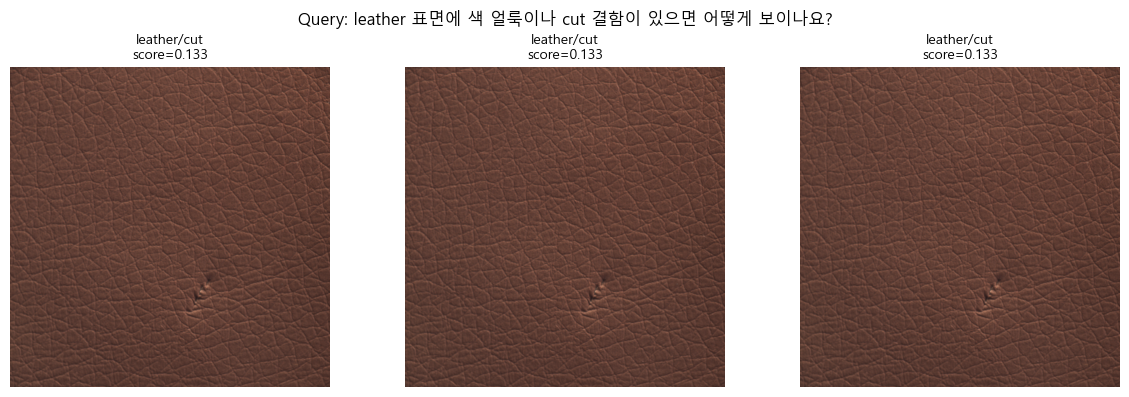

- **색 얼룩**: 참고 이미지에서 보이는 표면은 전체적으로 주로 **카키색**이며, **색 얼룩**이 보이지 않습니다.
- **cut 결함**: 참고 이미지에서 보이는 표면은 **정상적인 외관**을 유지하고 있으며, **cut 결함**이 보이지 않습니다.

결론적으로, 참고 이미지의 색 얼룩이나 cut 결함은 보이지 않습니다.


In [18]:
# === 텍스트 질의 예시 ===
# 질문 문장만 바꿔도 전체 Visual RAG가 다시 돌아갑니다.
USER_QUESTION = "leather 표면에 색 얼룩이나 cut 결함이 있으면 어떻게 보이나요?"
out = visual_rag_chain.invoke(USER_QUESTION)
print(out["answer"])

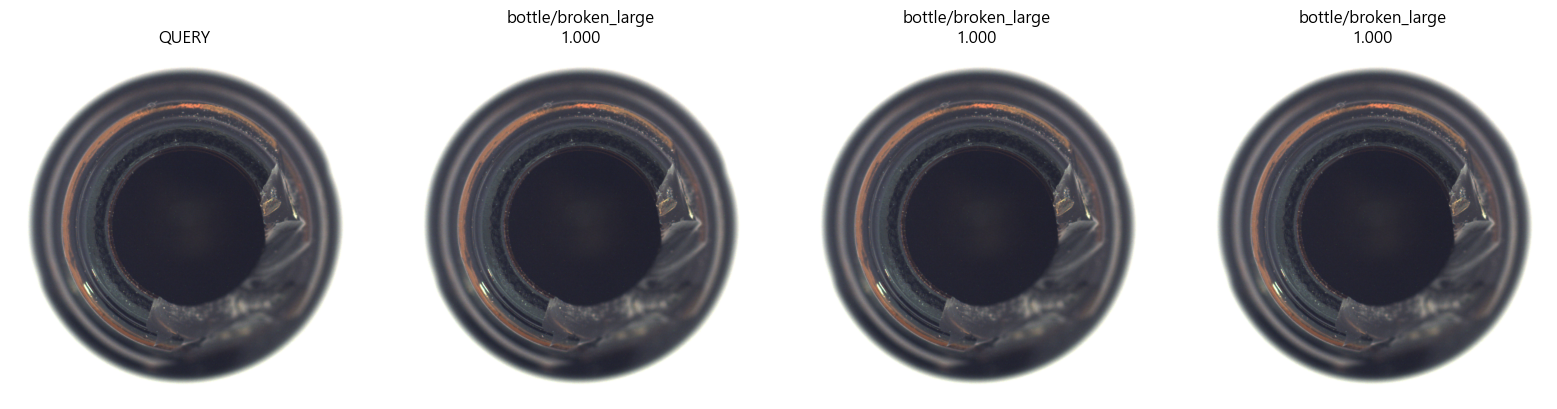

정상/결함: 결함
결함 유형: 외부 결함 (부분적 파손)

이미지의 상태를 분석할 때, 검사 대상 이미지의 가장 큰 특징은 외부에 있는 파손된 부분입니다. 이 부분은 원래의 뚜껑이 아닌, 외부에 있는 것으로 보이며, 투명한 플라스틱 재질의 뚜껑이 흐르고 있는 것을 볼 수 있습니다. 이는 외부에 있는 파손된 부분이므로, 외부 결함을 의미합니다. 참고 이미지의 메타데이터를 통해, 이 결함은 'broken_large' 라는 라벨을 가진 정상/결함 분류에 해당합니다. 따라서, 이 이미지의 상태는 외부 결함(부분적 파손)을 나타냅니다.


In [19]:
# === 이미지 진단 예시 ===
# QUERY_IMG = r"./data/mvtec/bottle/test/broken_large/000.png"  # 경로에 맞게 수정
QUERY_IMG = query_image  # 위에서 고른 샘플 재사용
out_img = visual_rag_by_image(QUERY_IMG)
print(out_img["answer"])

## 참고 / 팁

- **VRAM**: Qwen3-VL-2B + SigLIP2 So400M 동시 로드 시 GPU 약 8~12GB 권장. CPU도 동작하나 생성은 느립니다.
- **전체 인덱싱**: `MAX_IMAGES_PER_CATEGORY = None` 으로 설정하면 수집된 이미지를 모두 인덱싱합니다.
- **특정 카테고리만**: `CATEGORIES = ["bottle", "cable", "screw"]`
- **재인덱싱**: 5번 셀을 다시 실행하면 컬렉션을 재생성합니다.
- **서버형 Qdrant**: `QdrantClient(url="http://localhost:6333")` 로 교체 가능합니다.
- 이 폴더의 `requirements.txt`로 의존성을 설치하세요.

### 용어 빠른 정리
| 용어 | 쉬운 설명 |
|------|-----------|
| 임베딩 | 문장/이미지를 숫자 벡터로 바꾼 결과 |
| 벡터 DB | 비슷한 벡터를 빠르게 찾는 저장소 |
| Retriever | 질문에 맞는 근거(이미지/문서)를 찾아주는 부품 |
| VLM | 이미지를 보고 글을 생성하는 AI |
| Agent | 상황에 맞게 도구를 골라 쓰고 답을 정리하는 시스템 |
| Tool | Agent가 호출할 수 있는 함수(검색/진단 등) |
| create_agent | LangChain에서 모델+도구로 Agent 그래프를 만드는 함수 |
